In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

RAW            = '../data/bus_2025-07-28_2025-08-03.parquet'
DROP_THRESHOLD = 100

## 1. 加载数据，获取每个 drop 行的门状态

假设：
- drop 时门状态 = 1（开）→ drop 发生在 **arrival**（车已到站并开门）
- drop 时门状态 = 0（关）→ drop 发生在 **departure**（车关门后离站）

如果路线内一致，则可以对每条线路校准 drop 的语义。

In [2]:
# 读原始数据，只保留需要的列
raw = (
    pl.read_parquet(RAW, columns=['tst_iso', 'fzg_id', 'distanz', 'tuerkriterium'])
    .with_columns(pl.col('tst_iso').str.to_datetime(format='%Y-%m-%dT%H:%M:%S%.f%z'))
    .sort(['fzg_id', 'tst_iso'])
    .with_columns(
        pl.int_range(pl.len()).over('fzg_id').alias('row_idx')
    )
)

# 读 stop events
se = pl.read_parquet('../data/processed/core_stop_events.parquet')

# join：取 drop_row_idx 那一行的 tuerkriterium
door_at_drop = (
    se
    .filter(pl.col('stop_status') != 'no_door')
    .join(
        raw.select(['fzg_id', 'row_idx', 'tuerkriterium']),
        left_on  = ['fzg_id', 'drop_row_idx'],
        right_on = ['fzg_id', 'row_idx'],
        how      = 'left',
    )
    .rename({'tuerkriterium': 'door_at_drop'})
    .with_columns(
        pl.when(pl.col('door_at_drop') == True)
          .then(pl.lit('arrival'))
          .otherwise(pl.lit('departure'))
          .alias('drop_type')
    )
)

print(f'有效停站事件（normal/multi_door）: {len(door_at_drop):,}')
print()
print('drop 时门状态整体分布:')
print(door_at_drop['drop_type'].value_counts())

有效停站事件（normal/multi_door）: 778,889

drop 时门状态整体分布:
shape: (2, 2)
┌───────────┬────────┐
│ drop_type ┆ count  │
│ ---       ┆ ---    │
│ str       ┆ u32    │
╞═══════════╪════════╡
│ departure ┆ 615864 │
│ arrival   ┆ 163025 │
└───────────┴────────┘


## 2. 按路线（linie）统计 drop 类型比例

In [3]:
linie_stats = (
    door_at_drop
    .group_by('linie')
    .agg([
        pl.len().alias('total'),
        (pl.col('door_at_drop') == True).sum().alias('arrival_drops'),
        (pl.col('door_at_drop') == False).sum().alias('departure_drops'),
    ])
    .with_columns([
        (pl.col('arrival_drops') / pl.col('total') * 100).round(1).alias('pct_arrival'),
        (pl.col('departure_drops') / pl.col('total') * 100).round(1).alias('pct_departure'),
    ])
    .sort('linie')
)

print(linie_stats.to_pandas().to_string(index=False))

 linie  total  arrival_drops  departure_drops  pct_arrival  pct_departure
     1  29511           1101             1642          3.7            5.6
     2  39708              6              377          0.0            0.9
     3  35340              0               51          0.0            0.1
     4  54274             13              182          0.0            0.3
     6  30165            189              380          0.6            1.3
     7  49415              3              119          0.0            0.2
     8  20946            184              523          0.9            2.5
     9  26694              0                0          0.0            0.0
    10  22349            159              320          0.7            1.4
    11  40327              0               91          0.0            0.2
    12  28922            223              352          0.8            1.2
    13  31331              8               83          0.0            0.3
    47   5354            476          

## 3. 可视化：每条线路 arrival vs departure 比例

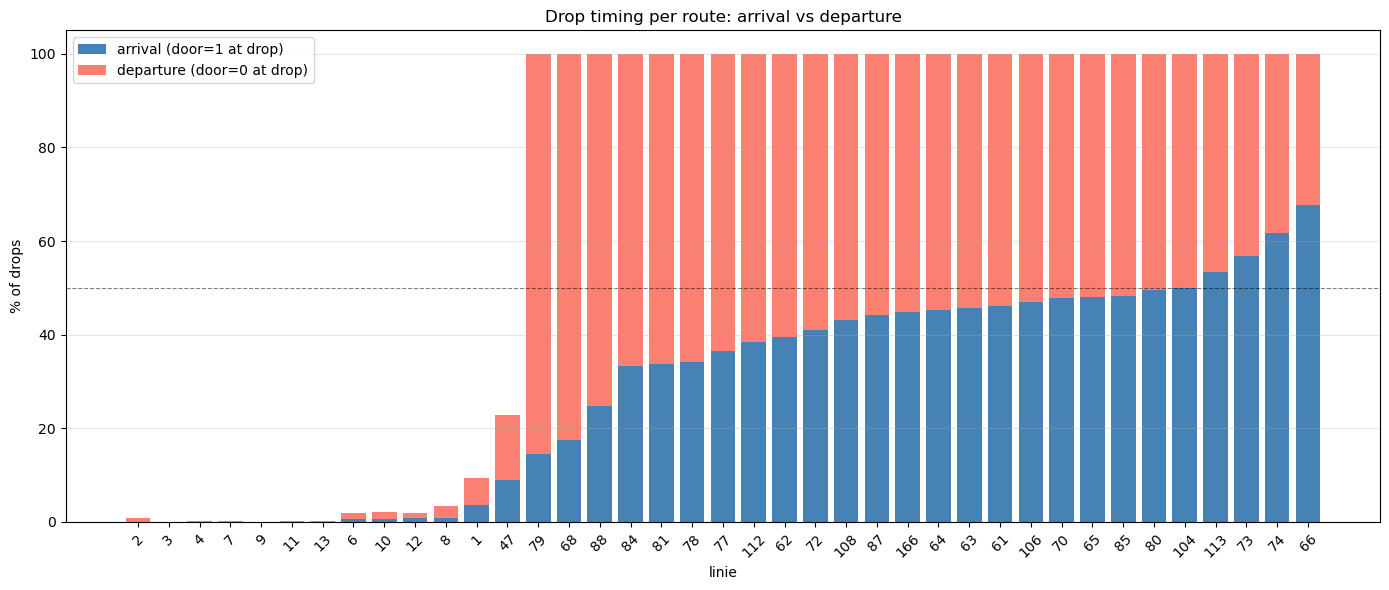

In [4]:
df_plot = linie_stats.sort('pct_arrival').to_pandas()

fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(df_plot))
ax.bar(x, df_plot['pct_arrival'],   label='arrival (door=1 at drop)',   color='steelblue')
ax.bar(x, df_plot['pct_departure'], bottom=df_plot['pct_arrival'],
       label='departure (door=0 at drop)', color='salmon')

ax.axhline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_xticks(list(x))
ax.set_xticklabels(df_plot['linie'].astype(str), rotation=45)
ax.set_xlabel('linie')
ax.set_ylabel('% of drops')
ax.set_title('Drop timing per route: arrival vs departure')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 一致性检验：每辆车内部是否一致

如果路线内 drop 语义一致，同一辆车（运营同一条线路）的 drop 类型应该高度一致。

In [5]:
vehicle_consistency = (
    door_at_drop
    .group_by(['fzg_id', 'linie'])
    .agg([
        pl.len().alias('total'),
        (pl.col('door_at_drop') == True).sum().alias('arrival_drops'),
    ])
    .filter(pl.col('total') >= 5)   # 排除样本量太少的
    .with_columns(
        (pl.col('arrival_drops') / pl.col('total') * 100).alias('pct_arrival')
    )
)

# 每条线路内，各车辆 pct_arrival 的分布（看是否集中在 0 或 100）
linie_consistency = (
    vehicle_consistency
    .group_by('linie')
    .agg([
        pl.len().alias('n_vehicles'),
        pl.col('pct_arrival').mean().round(1).alias('mean_pct_arrival'),
        pl.col('pct_arrival').std().round(1).alias('std_pct_arrival'),
        pl.col('pct_arrival').min().round(1).alias('min_pct_arrival'),
        pl.col('pct_arrival').max().round(1).alias('max_pct_arrival'),
    ])
    .sort('linie')
)

print('每条线路内各车辆的 arrival% 一致性（std 越小越一致）:')
print(linie_consistency.to_pandas().to_string(index=False))

每条线路内各车辆的 arrival% 一致性（std 越小越一致）:
 linie  n_vehicles  mean_pct_arrival  std_pct_arrival  min_pct_arrival  max_pct_arrival
     1          32               4.3             12.2              0.0             43.7
     2          22               0.0              0.0              0.0              0.2
     3          39               0.0              0.0              0.0              0.0
     4         102               0.9              6.3              0.0             50.0
     6          63               0.6              4.7              0.0             37.5
     7          40               0.7              4.5              0.0             28.6
     8          23               1.6              7.8              0.0             37.3
     9          49               0.0              0.0              0.0              0.0
    10          78               1.2              6.1              0.0             41.0
    11          33               0.0              0.0              0.0              0

## 5. 聚类：哪些线路是 "arrival-drop"，哪些是 "departure-drop"

以 pct_arrival 为标准，将路线分为三类：
- **arrival-drop**：pct_arrival > 70%
- **departure-drop**：pct_arrival < 30%
- **mixed / unclear**：30%–70%

In [6]:
classified = (
    linie_stats
    .with_columns(
        pl.when(pl.col('pct_arrival') > 70).then(pl.lit('arrival-drop'))
          .when(pl.col('pct_arrival') < 30).then(pl.lit('departure-drop'))
          .otherwise(pl.lit('mixed'))
          .alias('drop_category')
    )
    .sort('drop_category')
)

for cat in ['arrival-drop', 'departure-drop', 'mixed']:
    sub = classified.filter(pl.col('drop_category') == cat)
    linien = sub['linie'].to_list()
    print(f"{cat} ({len(linien)} 条线): {linien}")

arrival-drop (0 条线): []
departure-drop (16 条线): [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 47, 68, 79, 88]
mixed (23 条线): [61, 62, 63, 64, 65, 66, 70, 72, 73, 74, 77, 78, 80, 81, 84, 85, 87, 104, 106, 108, 112, 113, 166]


## 6. 单站示例：drop 周围门状态时序

从 arrival-drop 和 departure-drop 线路各取几个停站，可视化 drop 行附近的 tuerkriterium 时序，直观确认分类是否正确。

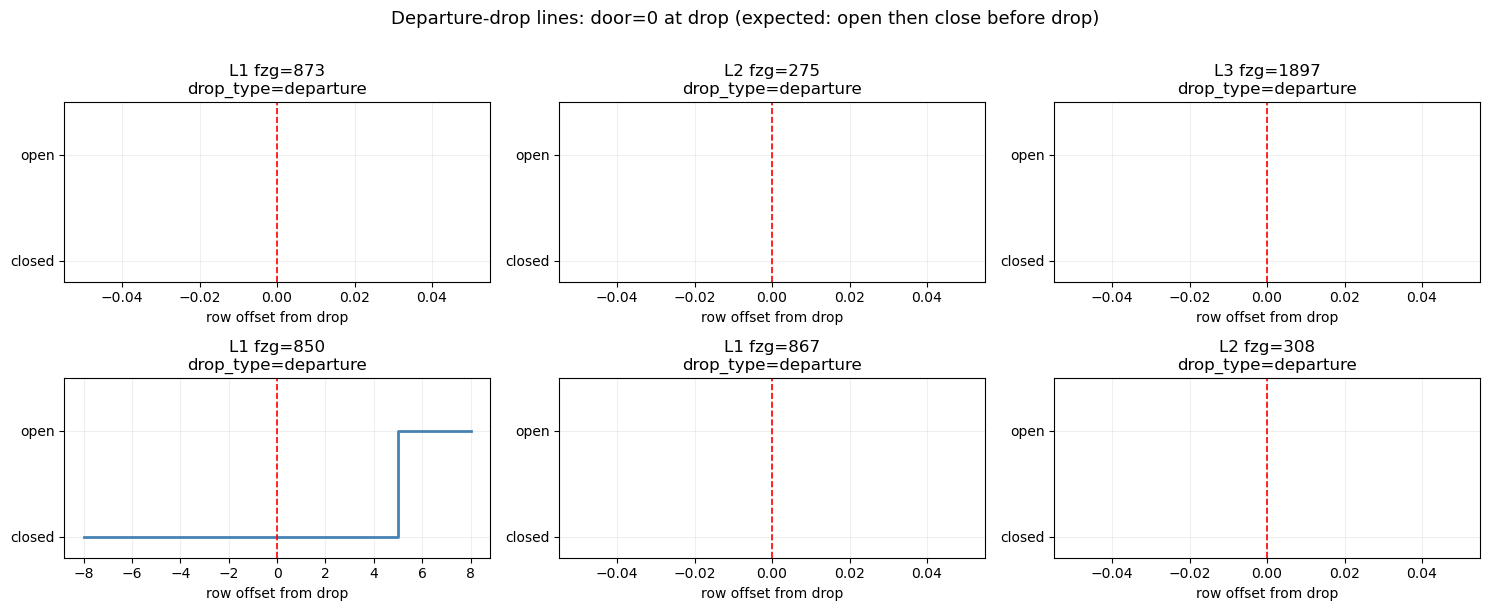

In [7]:
# 取分类结果
linie_category = dict(zip(classified['linie'].to_list(), classified['drop_category'].to_list()))

arrival_linien   = [l for l, c in linie_category.items() if c == 'arrival-drop']
departure_linien = [l for l, c in linie_category.items() if c == 'departure-drop']

# 用带 row_idx 的原始数据
raw_with_idx = raw  # already has row_idx

def plot_stops(sample_events, title, n_cols=3):
    n = len(sample_events)
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
    axes = np.array(axes).flatten()

    for ax, row in zip(axes, sample_events.iter_rows(named=True)):
        vid          = row['fzg_id']
        drop_idx     = row['drop_row_idx']
        drop_type    = row['drop_type']
        linie        = row['linie']

        win = (
            raw_with_idx
            .filter(pl.col('fzg_id') == vid)
            .filter(pl.col('row_idx').is_between(drop_idx - 8, drop_idx + 8))
            .sort('row_idx')
        )

        t    = win['row_idx'].to_numpy() - drop_idx
        door = win['tuerkriterium'].cast(pl.Int32).to_numpy()

        ax.step(t, door, where='post', color='steelblue', linewidth=2)
        ax.axvline(0, color='red', linestyle='--', linewidth=1.2, label='drop')
        ax.set_ylim(-0.2, 1.5)
        ax.set_yticks([0, 1])
        ax.set_yticklabels(['closed', 'open'])
        ax.set_xlabel('row offset from drop')
        ax.set_title(f'L{linie} fzg={vid}\ndrop_type={drop_type}')
        ax.grid(alpha=0.2)

    for ax in axes[len(sample_events):]:
        ax.set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

# arrival-drop 示例
if arrival_linien:
    sample_arr = (
        door_at_drop
        .filter(pl.col('linie').is_in(arrival_linien[:3]))
        .filter(pl.col('drop_type') == 'arrival')
        .sample(6, seed=42)
    )
    plot_stops(sample_arr, 'Arrival-drop lines: door=1 at drop (expected: open before/at drop)')

# departure-drop 示例
if departure_linien:
    sample_dep = (
        door_at_drop
        .filter(pl.col('linie').is_in(departure_linien[:3]))
        .filter(pl.col('drop_type') == 'departure')
        .sample(6, seed=42)
    )
    plot_stops(sample_dep, 'Departure-drop lines: door=0 at drop (expected: open then close before drop)')